<a href="https://colab.research.google.com/github/vinayprabhu/zampa/blob/main/code/zampa_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import time
%matplotlib inline

from scipy.linalg import block_diag
# Don't do linear algebra in Python without these two lines
np.set_printoptions(suppress=True)
from collections import Counter
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')


def tic():
    global _start_time
    _start_time = time.perf_counter()

def toc():
    elapsed = time.perf_counter() - _start_time
    print(f"Elapsed time is {elapsed:.4f} seconds.")

%precision 3
#############################################
import sys
import importlib
importlib.reload(sys)
#######################
from google.colab import drive
drive.flush_and_unmount()
import os
drive.mount('/gdrive', force_remount=True)
# Enter your own proj_dir here
proj_dir='/gdrive/My Drive/ZAMPA/'
os.chdir(proj_dir)

/tmp/ipykernel_1822/1086975545.py:14: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


Drive not mounted, so nothing to flush and unmount.
Mounted at /gdrive


In [2]:
# !git clone https://gitlab.com/machine-biology-group-public/apex-pathogen
# !git clone https://gitlab.com/machine-biology-group-public/apex
# Clone the APEX model repos if you haven't done that yet!

In [3]:
from combined_apex_mic_new import predict_apex_mics
# mode can take these values: "all_1", "all_pathogen", "both", "subset_1", "median"
# result = predict_apex_mics(
#     ["KWKLFKKIEKVGQNIRDGIIKAGPAVAVVGQATQIAK"],
#     apex10_repo="./apex",
#     apex11_repo="./apex-pathogen",
# )
# result

In [4]:
#@ Read the top 100 peptides from all the 4 models (GPT only output 6)
df_top100=pd.read_csv('df_top100_all.csv')
print(df_top100.shape)
list_306=list(df_top100.peptide.values)
list_306

(306, 2)


['FSIYRLVWRQIRRVAQTCAR',
 'PLIKRFVKRIWSTVRH',
 'FRIIGSWWRSFKRHFKFIYQ',
 'AIKRCISRWHRSLRAA',
 'LKSLTRKATWLVRSWAR',
 'GASIIRQVKKFFRKFGW',
 'WRLIKTFFTIVRHSTRRA',
 'FWRLPRAAPRWLLRYLTRGVR',
 'KKLWRFIKRFVNSGSNGLGTLLS',
 'RRAFKRFNTWIRISLRVVN',
 'KCLTRIHVALSRAIPRAIKHW',
 'RRLIWKILHLCKLAPR',
 'RGTRKFFNGIGRWVRFCAIS',
 'RNFAPKLFRLFPRMIR',
 'SIVSWAKKWLRRIGKGVK',
 'RIALRWLQNTVRCLIRQ',
 'GATLIKQVKRLIKKLGW',
 'IRIRQRLYKWVLNPIR',
 'RSAIRHPNRFFRMIRSVV',
 'RKILNRFYWILKRGLA',
 'QIIGRKLRFGIKAWKRFI',
 'RSIITLLGHWRRIVRG',
 'RVLAKMLRSVWRIITRKPRL',
 'RSIKSINKLIRRLVSWPAIT',
 'KRFWKAIKRAINSGTTGIQKLAS',
 'ARLRNSPQRWLSLVARSVGRV',
 'RNVNKLWGRPVRFAASI',
 'KHVWRFVKKLVGSGRTGLQQLAS',
 'QIVKLAVHIYRAWKRR',
 'IKGRIQRAFSWMWRSLAKI',
 'VTQKFIQNVIYFVRALGRWNKK',
 'RRWTKPIKLFNRLFAIYY',
 'KKFWKVFKKAFNSGNTGLQTLAS',
 'GATAIKQLKRLLKKWGW',
 'GATLIKQVKKFFKRAGW',
 'YYLQMGLTLIRRVHKLFKRWGW',
 'GIKRWLRKGARHFGQLLIK',
 'ILPKSYRWHKSAIRIAK',
 'YVTKRAKKGWRGLVSLV',
 'RKVPSILLRIWR',
 'KKWVKFIKKAVQSGTTGLQTLAS',
 'IKSPWRNLVRVAWSVRRLYK',
 'KNLRKI

In [5]:
tic()
df_mic = predict_apex_mics(
    list_306,
    apex10_repo="./apex",
    apex11_repo="./apex-pathogen",
)
df_mic.reset_index(drop=False,inplace=True)
df_mic['model']=df_top100.model.values
toc()

Elapsed time is 108.1709 seconds.


In [6]:
df_mic_306=df_mic.loc[:,['model', 'peptide_sequence',
                        'APEX_1.0 | E. coli ATCC11775',
                        'APEX_1.0 | P. aeruginosa PAO1',
                        'APEX_1.0 | P. aeruginosa PA14',
                        'APEX_1.0 | S. aureus ATCC12600',
                        'APEX_1.0 | E. coli AIG221',
                        'APEX_1.0 | E. coli AIG222',
                        'APEX_1.0 | K. pneumoniae ATCC13883',
                        'APEX_1.0 | A. baumannii ATCC19606',
                        'APEX_1.0 | A. muciniphila ATCC BAA-835',
                        'APEX_1.0 | B. fragilis ATCC25285',
                        'APEX_1.0 | B. vulgatus ATCC8482',
                        'APEX_1.0 | C. aerofaciens ATCC25986',
                        'APEX_1.0 | C. scindens ATCC35704',
                        'APEX_1.0 | B. thetaiotaomicron ATCC29148',
                        'APEX_1.0 | B. thetaiotaomicron Complemmented',
                        'APEX_1.0 | B. thetaiotaomicron Mutant',
                        'APEX_1.0 | B. uniformis ATCC8492',
                        'APEX_1.0 | B. eggerthi ATCC27754',
                        'APEX_1.0 | C. spiroforme ATCC29900',
                        'APEX_1.0 | P. distasonis ATCC8503',
                        'APEX_1.0 | P. copri DSMZ18205',
                        'APEX_1.0 | B. ovatus ATCC8483',
                        'APEX_1.0 | E. rectale ATCC33656',
                        'APEX_1.0 | C. symbiosum',
                        'APEX_1.0 | R. obeum',
                        'APEX_1.0 | R. torques',
                        'APEX_1.0 | S. aureus (ATCC BAA-1556) - MRSA',
                        'APEX_1.0 | vancomycin-resistant E. faecalis ATCC700802',
                        'APEX_1.0 | vancomycin-resistant E. faecium ATCC700221',
                        'APEX_1.0 | E. coli Nissle',
                        'APEX_1.0 | Salmonella enterica ATCC 9150 (BEIRES NR-515)',
                        'APEX_1.0 | Salmonella enterica (BEIRES NR-170)',
                        'APEX_1.0 | Salmonella enterica ATCC 9150 (BEIRES NR-174)',
                        'APEX_1.0 | L. monocytogenes ATCC 19111 (BEIRES NR-106)',
                        'APEX_1.1 | A. baumannii ATCC 19606',
                        'APEX_1.1 | E. coli ATCC 11775',
                        'APEX_1.1 | E. coli AIC221',
                        'APEX_1.1 | E. coli AIC222',
                        'APEX_1.1 | K. pneumoniae ATCC 13883',
                        'APEX_1.1 | P. aeruginosa PA01',
                        'APEX_1.1 | P. aeruginosa PA14',
                        'APEX_1.1 | S. aureus ATCC 12600',
                        'APEX_1.1 | S. aureus (ATCC BAA-1556) - MRSA',
                        'APEX_1.1 | vancomycin-resistant E. faecalis ATCC 700802',
                        'APEX_1.1 | vancomycin-resistant E. faecium ATCC 700221']
                      ]

In [7]:
df_mic_306.to_csv('df_mic_306.tsv',index=False,sep='\t')
df_mic_306.shape

(306, 47)

In [8]:
tic()
df_mic_median = predict_apex_mics(
    list_306,
    apex10_repo="./apex",
    apex11_repo="./apex-pathogen",
    mode="median"
)
df_mic_median.reset_index(drop=False,inplace=True)
df_mic_median['model']=df_top100.model.values
toc()

Elapsed time is 10.1708 seconds.


In [9]:
col_10=df_mic_median.columns[1]
col_11=df_mic_median.columns[2]
print(col_10,col_11)

APEX_1.0 | median MIC across matched 11 strains APEX_1.1 | median MIC across 11 strains


In [10]:

# Find the best peptide sequence for each generative model based on APEX 1.0 MIC
best_10_idx = df_mic_median.groupby('model')[col_10].idxmin()
best_apex_10_per_model = df_mic_median.loc[best_10_idx, ['model', 'peptide_sequence', col_10]]

# Find the best peptide sequence for each generative model based on APEX 1.1 MIC
best_11_idx = df_mic_median.groupby('model')[col_11].idxmin()
best_apex_11_per_model = df_mic_median.loc[best_11_idx, ['model', 'peptide_sequence', col_11]]

print("--- Best Peptides per Generative Model (APEX 1.0) ---")
print(best_apex_10_per_model.to_string(index=False))

print("\n--- Best Peptides per Generative Model (APEX 1.1) ---")
print(best_apex_11_per_model.to_string(index=False))

--- Best Peptides per Generative Model (APEX 1.0) ---
 model         peptide_sequence  APEX_1.0 | median MIC across matched 11 strains
abacus           KRWPRWRKLRILFK                                        13.646861
claude           KRRVWKRIKWLKKV                                        13.593804
edison     RVLAKMLRSVWRIITRKPRL                                        24.414393
   gpt KLGWRVNLKITSKLKLKVRLALKT                                        14.192100

--- Best Peptides per Generative Model (APEX 1.1) ---
 model   peptide_sequence  APEX_1.1 | median MIC across 11 strains
abacus  KKFFLKRLKRWFILKKW                                18.808751
claude      RKKRKLFRRLWRI                                26.222639
edison   SWKLHKLMLRVLKRNL                                22.441476
   gpt SVLGKIRVRLKIRLKIRW                                11.420175


In [11]:
# Filter for peptides with < 32 MIC on both APEX models
mask = (df_mic_median[col_10] < 32) & (df_mic_median[col_11] < 32)
df_filtered = df_mic_median[mask].copy()

# Calculate combined MIC for the tie-breaker
df_filtered['combined_mean_mic'] = (df_filtered[col_10] + df_filtered[col_11])/2

# Select the sequence with minimum combined MIC for each generative model
best_per_model_idx = df_filtered.groupby('model')['combined_mean_mic'].idxmin()
df_best_per_model = df_filtered.loc[best_per_model_idx, ['model', 'peptide_sequence', col_10, col_11, 'combined_mean_mic']]

print("--- Best Peptide Sequence Per Model (Both MICs < 32) ---")
print(df_best_per_model.to_string(index=False))

--- Best Peptide Sequence Per Model (Both MICs < 32) ---
 model         peptide_sequence  APEX_1.0 | median MIC across matched 11 strains  APEX_1.1 | median MIC across 11 strains  combined_mean_mic
abacus        KKFFLKRLKRWFILKKW                                        14.106419                                18.808751          16.457585
claude           KRIIRRRKLWIRRW                                        21.252342                                28.416759          24.834550
edison         SWKLHKLMLRVLKRNL                                        27.610715                                22.441476          25.026095
   gpt KLGWRVNLKITSKLKLKVRLALKT                                        14.192100                                12.391268          13.291684


In [12]:
df_best_per_model

,model,peptide_sequence,APEX_1.0 | median MIC across matched 11 strains,APEX_1.1 | median MIC across 11 strains,combined_mean_mic
272,abacus,KKFFLKRLKRWFILKKW,14.106419,18.808751,16.457585
133,claude,KRIIRRRKLWIRRW,21.252342,28.416759,24.834550
65,edison,SWKLHKLMLRVLKRNL,27.610715,22.441476,25.026095
204,gpt,KLGWRVNLKITSKLKLKVRLALKT,14.192100,12.391268,13.291684


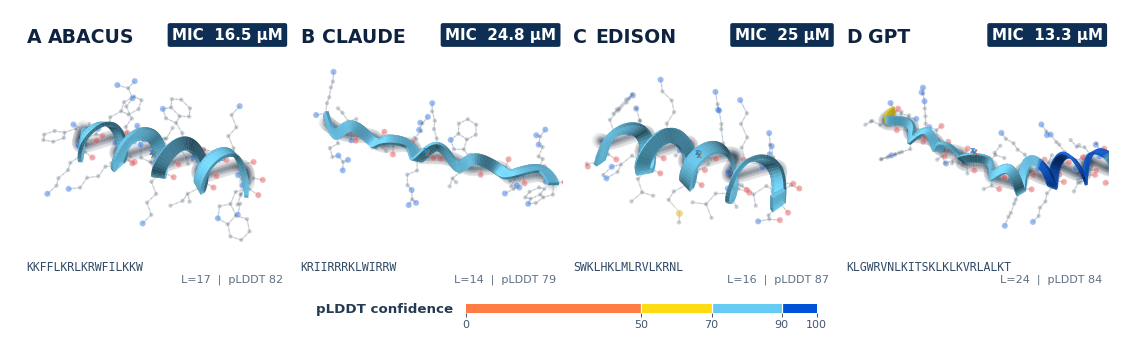

{'png': '/gdrive/MyDrive/VAMPIRE/ZS/final.png',
 'pdf': '/gdrive/MyDrive/VAMPIRE/ZS/final.pdf',
 'mean_plddt': {'ABACUS': 81.647,
  'CLAUDE': 79.357,
  'EDISON': 86.625,
  'GPT': 84.208}}

In [13]:
from plt_peptides_1x4grid import generate_amp_structure_figure

generate_amp_structure_figure(list(df_best_per_model.peptide_sequence),
                              list(df_best_per_model.combined_mean_mic),
                              "final",
                              model_names=list(df_best_per_model.model.str.upper())
)